# 아산시 방송효과 통합 분석 (입체 버전) v0.25

기존 step1~10을 한 노트북으로 통합하고, 방법론을 더 엄격하게 보강.
**데이터 기준**: 압축 푼 CSV 폴더 (config의 CARD_DIR 등), 카드는 `CRTR_WEEK` 주 단위.

### v0.25 변경사항 (v0.24 대비)
1. **DID 표준오차** — HC1(이분산 강건 SE) 적용, p-value 과소추정 방지
2. **Placebo test 추가** — 가짜 방영일로 DID를 돌려 효과 부재 확인
3. **카드 ROI 재산출** — DID 기반 순효과(통제군 차감)로 ROI 계산 (raw 전후비교 폐기)
4. **데이터랩 CausalImpact** — 방송별 분리 해석 제거, 시 전체 배경지표로만 활용
5. **메타회귀 삭제** — N=6으로 OLS 부적절, 기술통계 막대그래프만 유지
6. **Moran's I** — 순열 검정 p-value 추가
7. **코드 정리** — Part 번호 재정렬, 하드코딩 제거, side effect 방지

### 구성
- Part 0 기반 / Part 1 데이터레이어 / Part 2 교란통제 / Part 3 인과추론(5종)
- Part 4 경제효과 / Part 5 조절분석 / Part 6 공간분석 / Part 7 교차검증·리포트

## Part 0 — 공통 기반

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import warnings, re, glob, zipfile, os
from pathlib import Path
warnings.filterwarnings('ignore')

# ============================================================
# config.py에 의존하지 않고 노트북이 자립한다 (버전 충돌/경로 문제 회피)
# ============================================================
# ★ 데이터 루트: 실제 위치로 지정 (탐색기에서 확인된 경로)
BASE = Path(r"C:\Users\admin\Desktop\작업 폴더\01. work\02. 프로젝트\아산시\방송")
DATA_DIR = BASE / "01.데이터"
OUTPUT_DIR = BASE / "02.분석결과"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 하위 폴더 (실제 폴더명에 맞게 자동 탐색 — 이름이 조금 달라도 잡히도록)
def _find_dir(parent, *keywords):
    for p in parent.iterdir() if parent.exists() else []:
        if p.is_dir() and all(k in p.name for k in keywords):
            return p
    return parent / keywords[0]  # 폴백

CARD_DIR = _find_dir(DATA_DIR, "카드")
TMAP_DIR = _find_dir(DATA_DIR, "내비") if _find_dir(DATA_DIR,"내비").exists() else _find_dir(DATA_DIR,"비게")
POP_DIR  = _find_dir(DATA_DIR, "인구")
print("CARD_DIR:", CARD_DIR, "| exists:", CARD_DIR.exists())
print("TMAP_DIR:", TMAP_DIR, "| exists:", TMAP_DIR.exists())
print("POP_DIR :", POP_DIR,  "| exists:", POP_DIR.exists())

# ---- 자립 헬퍼: read_csv_auto / load_monthly_data / classify_tourism ----
def read_csv_auto(path, **kw):
    for enc in ['utf-8-sig','cp949','utf-8','euc-kr']:
        try: return pd.read_csv(path, encoding=enc, **kw)
        except UnicodeDecodeError: continue
    return pd.read_csv(path, encoding='utf-8', errors='replace', **kw)

def load_monthly_data(base_dir, pattern):
    """base_dir 하위에서 pattern 포함 CSV 전부 읽어 concat."""
    files = sorted(glob.glob(str(Path(base_dir) / '**' / f'*{pattern}*.csv'), recursive=True))
    dfs = [read_csv_auto(f) for f in files]
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

TOURISM_KEYWORDS = ['숙박','호텔','콘도','펜션','음식','한식','중식','양식','일식',
                    '카페','관광','레저','온천','놀이','테마','휴양','민속']
def classify_tourism(name):
    s = str(name)
    return next((k for k in TOURISM_KEYWORDS if k in s), '기타')

# ============================================================
# 방송 메타 (직접 정의 — config 불필요)
# ============================================================
WINDOW_PRE, WINDOW_POST = 28, 28
CORE_TOURISM_BIZ = [1001,1003,1010,1020,2199,7120]
FOOD_BIZ = [8001,8005,8006,8010,8013,8021,8301]
RETAIL_BIZ = [4010,4020,4004]

BROADCASTS = [
    {"name":"전국노래자랑 아산시편","broadcaster":"KBS1","genre":"음악예능",
     "air_date":"2025-06-08","air_end_date":"2025-06-08","rating":6.5,
     "budget_1000won":3518,"locations":["신정호 잔디광장"],
     "dong_names":["온양5동"],"confounders":["이순신축제(4~5월)"]},
    {"name":"전현무계획2","broadcaster":"MBN","genre":"여행버라이어티",
     "air_date":"2025-11-07","air_end_date":"2025-11-07","rating":1.5,
     "budget_1000won":50000,"locations":["아산시 일원(숨은맛집/명소)"],
     "dong_names":[],"confounders":[]},
    {"name":"굿모닝 대한민국","broadcaster":"KBS2","genre":"교양정보",
     "air_date":"2025-11-12","air_end_date":"2025-11-16","rating":0.55,
     "budget_1000won":20000,
     "locations":["온양온천역 광장","족욕체험장","온양온천 전통시장",
                  "곡교천 은행나무길","이순신 관광체험센터","현충사","피나클랜드"],
     "dong_names":["온양1동","염치읍","신창면"],"confounders":["가을단풍시즌(10~11월)"]},
    {"name":"6시 내고향","broadcaster":"KBS1","genre":"교양정보",
     "air_date":"2025-11-13","air_end_date":"2025-11-13","rating":5.5,
     "budget_1000won":110000,"locations":["아산시 주요명소"],
     "dong_names":[],"confounders":[]},
    {"name":"박원숙의 같이삽시다 시즌3","broadcaster":"KBS2","genre":"예능",
     "air_date":"2025-11-24","air_end_date":"2025-12-15","rating":3.0,
     "budget_1000won":133000,
     "locations":["곡교천 은행나무길","신정호정원","영인산","외암민속마을",
                  "온양온천시장","도고파라다이스","아산스파포레"],
     "dong_names":["염치읍","온양5동","영인면","송악면","온양1동","도고면","음봉면"],
     "confounders":["가을단풍시즌(10~11월)","겨울온천시즌(12월)"]},
    {"name":"뛰어야산다2","broadcaster":"MBN","genre":"스포츠리얼버라이어티",
     "air_date":"2026-01-12","air_end_date":"2026-01-12","rating":1.5,
     "budget_1000won":45000,
     "locations":["신정호정원","곡교천 은행나무길","현충사","온천","캠핑장"],
     "dong_names":["온양5동","염치읍","온양1동"],"confounders":["비수기(1월)"]},
    {"name":"황제성의 황제파워","broadcaster":"SBS파워FM","genre":"라디오공개방송",
     "air_date":"2026-05-09","air_end_date":"2026-05-09","rating":None,
     "budget_1000won":220000,"locations":["온양온천역 주무대"],
     "dong_names":["온양1동"],"confounders":["이순신축제(4~5월)"]},
]

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

bdf = pd.DataFrame(BROADCASTS)
bdf['air_date'] = pd.to_datetime(bdf['air_date'])
bdf['air_end_date'] = pd.to_datetime(bdf['air_end_date'])
DATA_END = pd.Timestamp('2026-04-30')
bdf['measurable'] = bdf['air_date'] <= DATA_END
AIR = dict(zip(bdf['name'], bdf['air_date']))
print(f"\n방송 {len(bdf)}건, 측정가능 {bdf['measurable'].sum()}건")
print(bdf[['name','genre','air_date','rating','measurable']].to_string(index=False))

CARD_DIR: C:\Users\admin\Desktop\작업 폴더\01. work\02. 프로젝트\아산시\방송\01.데이터\02. 카드매출 데이터 | exists: True
TMAP_DIR: C:\Users\admin\Desktop\작업 폴더\01. work\02. 프로젝트\아산시\방송\01.데이터\04. 내비게이션 데이터 | exists: True
POP_DIR : C:\Users\admin\Desktop\작업 폴더\01. work\02. 프로젝트\아산시\방송\01.데이터\01. 인구 데이터 | exists: True

방송 7건, 측정가능 6건
          name      genre   air_date  rating  measurable
   전국노래자랑 아산시편       음악예능 2025-06-08    6.50        True
        전현무계획2    여행버라이어티 2025-11-07    1.50        True
      굿모닝 대한민국       교양정보 2025-11-12    0.55        True
        6시 내고향       교양정보 2025-11-13    5.50        True
박원숙의 같이삽시다 시즌3         예능 2025-11-24    3.00        True
        뛰어야산다2 스포츠리얼버라이어티 2026-01-12    1.50        True
     황제성의 황제파워    라디오공개방송 2026-05-09     NaN       False


In [95]:
# ---- 공통 헬퍼: 주차코드→날짜, 동 이름 별칭, 업종 분류 ----
def week_to_monday(week_code, ym_code=None):
    if pd.isna(week_code): return pd.NaT
    s = str(int(week_code))
    if len(s) < 6: return pd.NaT
    yy, ww = int(s[:4]), int(s[4:])
    if 1 <= ww <= 53:
        try: return pd.Timestamp(dt.date.fromisocalendar(yy, ww, 1))
        except ValueError: pass
    if ym_code is not None and not pd.isna(ym_code):
        ym = str(int(ym_code))
        try:
            base = dt.date(int(ym[:4]), int(ym[4:6]), 1)
            return pd.Timestamp(base + dt.timedelta(days=(max(ww,1)-1)*7))
        except Exception: return pd.NaT
    return pd.NaT

# config는 온양1~6동을 쓰지만 데이터 표기 확인용 별칭 (필요시 확장)
def expand_to_data(dong_names, data_dongs):
    out = set()
    ds = set(data_dongs)
    for d in dong_names:
        if d in ds: out.add(d)
        else: out |= {x for x in ds if d in str(x) or str(x) in d}
    return sorted(out)

TOURISM_BIZ = set(CORE_TOURISM_BIZ + FOOD_BIZ)
def is_tourism_biz(code):
    try: return int(code) in TOURISM_BIZ
    except Exception: return False

## Part 1 — 데이터 레이어

카드(외지인 소비, 주 단위·관광업종 분리), T맵(관광지 일별·출발지), SKT(가능 구간).


In [96]:
# ---- 카드: 외지인(EXCL_RSDT) 주간 소비 로드 ----
import glob
def load_card_weekly():
    pats = ['WEEK_CCND_EXCL_RSDT_CRTR_CCND_CSPT_DONG',
            'WEEK_CCND_CUST_CRTR_CCND_EXCL_LC_CSPT_DONG']  # 주/강건성
    for pat in pats:
        files = sorted(glob.glob(str(CARD_DIR / '**' / f'*{pat}*.csv'), recursive=True))
        if files:
            print(f"패턴 매칭: {pat} ({len(files)}개 파일)")
            dfs = []
            for f in files:
                for enc in ['utf-8-sig','cp949','utf-8']:
                    try: dfs.append(pd.read_csv(f, encoding=enc)); break
                    except UnicodeDecodeError: continue
            return pd.concat(dfs, ignore_index=True), pat
    return pd.DataFrame(), None

card, card_pat = load_card_weekly()
print("카드 로드:", card.shape)
if len(card):
    print("컬럼:", list(card.columns)[:20])

패턴 매칭: WEEK_CCND_EXCL_RSDT_CRTR_CCND_CSPT_DONG (16개 파일)
카드 로드: (541322, 41)
컬럼: ['CRTR_WEEK', 'CUST_CTPV_NM', 'CUST_SGG_NM', 'CUST_DONG_NM', 'CUST_DONG_CD', 'FRCS_CTPV_NM', 'FRCS_SGG_NM', 'FRCS_DONG_NM', 'FRCS_DONG_CD', 'TOBIZ_CD', 'TOBIZ_NM', 'FRCS_SLS_SZ', 'ALL_USE_NOCS', 'INDIV_USE_NOCS', 'CORP_USE_NOCS', 'ML_USE_NOCS', 'FM_USE_NOCS', 'TEEN_BELOW_USE_NOCS', 'TEEN_USE_NOCS', 'TWT_USE_NOCS']


In [97]:
# ---- 외지인 가맹점 위치(FRCS_DONG) 기준 주간 패널 (전체 + 관광업종) ----
def build_card_panel(df):
    df = df.copy()
    # 아산시 가맹점만
    if 'FRCS_SGG_NM' in df.columns:
        df = df[df['FRCS_SGG_NM'] == '아산시']
    dong_c = next((c for c in df.columns if 'FRCS' in c and 'DONG' in c and 'NM' in c), 'FRCS_DONG_NM')
    amt_c = 'ALL_USE_AMT' if 'ALL_USE_AMT' in df.columns else next(c for c in df.columns if 'AMT' in c.upper())
    biz_c = next((c for c in df.columns if 'TOBIZ' in c and ('CD' in c or 'NM' in c)), None)
    df['period'] = df['CRTR_WEEK'].astype('Int64').astype(str)
    ymc = 'CRTR_YM' if 'CRTR_YM' in df.columns else None
    df['week_start'] = [week_to_monday(w, (df[ymc].iloc[i] if ymc else None))
                        for i, w in enumerate(df['CRTR_WEEK'].astype('Int64'))]
    df = df[df['week_start'].notna()]
    # 관광업종 플래그
    biz_code_c = next((c for c in df.columns if 'TOBIZ' in c and 'CD' in c), None)
    if biz_code_c:
        df['is_tour'] = df[biz_code_c].apply(is_tourism_biz)
    else:
        df['is_tour'] = True  # 업종 없으면 전체
    full = df.groupby([dong_c,'period','week_start'])[amt_c].sum().reset_index()
    tour = df[df['is_tour']].groupby([dong_c,'period','week_start'])[amt_c].sum().reset_index()
    return full, tour, dong_c, amt_c

card_full, card_tour, dong_col, amt_col = build_card_panel(card)
DATA_DONGS = sorted(card_full[dong_col].dropna().unique())
print("전체패널:", card_full.shape, "| 관광패널:", card_tour.shape)
print("동 목록:", DATA_DONGS)
print("기간:", card_full['week_start'].min().date(), "~", card_full['week_start'].max().date())

전체패널: (1156, 4) | 관광패널: (1153, 4)
동 목록: ['도고면', '둔포면', '배방읍', '선장면', '송악면', '신창면', '염치읍', '영인면', '온양1동', '온양2동', '온양3동', '온양4동', '온양5동', '온양6동', '음봉면', '인주면', '탕정면']
기간: 2024-12-30 ~ 2026-04-13


In [98]:
# ---- T맵: 관광지 매칭 + 일별 (2026년 35컬럼/2025년 34컬럼 혼재 안전 처리) ----
POI_KW = {
    "신정호": ["신정호"], "현충사": ["현충사"], "외암민속마을": ["외암","민속마을"],
    "곡교천": ["곡교천","은행나무"], "온양온천": ["온양온천","온천시장","족욕"],
    "도고온천": ["도고"], "피나클랜드": ["피나클"], "영인산": ["영인산"],
    "스파포레": ["스파포레"],
}
def match_poi(name):
    for poi, kws in POI_KW.items():
        if any(re.search(k, str(name)) for k in kws): return poi
    return None

tmap_files = sorted(glob.glob(str(TMAP_DIR / '**' / 'as_tmap_od_*.csv'), recursive=True))
tdfs = []
for f in tmap_files:
    df_one = None
    for enc in ['utf-8-sig','cp949','utf-8']:
        try:
            df_one = read_csv_auto(f); break
        except Exception as e:
            print(f"  [!] {os.path.basename(f)} 실패: {type(e).__name__}"); break
    if df_one is not None:
        df_one.columns = [str(c).strip().lower() for c in df_one.columns]  # 컬럼명 표준화
        tdfs.append(df_one)
print(f"로드: {len(tdfs)}/{len(tmap_files)} 파일")

# concat은 컬럼명 합집합으로 정렬 → 추가컬럼은 NaN, 공통컬럼은 안 밀림
tmap = pd.concat(tdfs, ignore_index=True, sort=False)
# 핵심 컬럼 존재 확인
assert 'drv_ymd' in tmap.columns, f"drv_ymd 없음. 실제 컬럼: {list(tmap.columns)[:10]}"
tmap['date'] = pd.to_datetime(tmap['drv_ymd'].astype('Int64').astype(str),
                              format='%Y%m%d', errors='coerce')
n_bad = tmap['date'].isna().sum()
if n_bad: print(f"  [!] 날짜 파싱 실패 {n_bad}행 제외")
tmap = tmap[tmap['date'].notna()]
tmap['poi'] = tmap['dstn_nm'].apply(match_poi)

print("\n월별 행 수 (2026 포함 확인):")
print(tmap['date'].dt.to_period('M').value_counts().sort_index().to_string())
print(f"\nT맵: {tmap.shape} | 관광지 매칭: {tmap['poi'].notna().sum()} "
      f"| 기간: {tmap['date'].min().date()} ~ {tmap['date'].max().date()}")

로드: 16/16 파일

월별 행 수 (2026 포함 확인):
date
2025-01    26311
2025-02    26393
2025-03    31735
2025-04    32144
2025-05    34213
2025-06    31516
2025-07    45257
2025-08    45438
2025-09    43298
2025-10    72316
2025-11    49886
2025-12    43129
2026-01    34290
2026-02    31348
2026-03    37545
2026-04    38527
Freq: M

T맵: (623346, 37) | 관광지 매칭: 48057 | 기간: 2025-01-01 ~ 2026-04-30


## Part 1.5 — 데이터랩: 관광소비·방문자 장기추세 (2018~2026)

읍면동 단위가 아닌 **아산시 전체** 월별 시계열이지만 **7년치**라 계절성·추세가 탄탄하고
외지인이 이미 분리돼 있다. 카드/T맵(2025~)으로 못 하는 것을 보강:
- **YoY**: `관광소비 추이`에 전년 지출액이 이미 포함 → 방송월 전년대비 즉시 비교
- **CausalImpact**: 아산 전체 외지인 소비/방문의 방송 전후 반사실 (장기 베이스라인)
- **방문자 구분**: 외지인/현지인 분리 → "사람이 왔나"의 공식 지표

⚠ 시 전체 단위라 읍면동 DID는 불가 → 그건 카드·T맵이 담당. 역할 분담.

In [99]:
# ---- 데이터랩 ZIP 로드 (재귀 glob + 키워드: 폴더명/공백에 안 휘둘림) ----
import zipfile
def read_datalab_series(area_kw, target_kw, require_kw=None):
    """BASE 아래 모든 ZIP 중 경로에 area_kw 포함된 것에서 target_kw CSV 수집.
    require_kw가 있으면 경로에 그 키워드(예 '외지인')도 포함된 것만."""
    rows = []
    zips = [z for z in BASE.glob('**/*.zip') if area_kw in str(z)]
    if require_kw:
        zips = [z for z in zips if require_kw in str(z)]
    print(f"  [{area_kw}{'/'+require_kw if require_kw else ''}] ZIP {len(zips)}개")
    for zp in zips:
        try:
            with zipfile.ZipFile(zp) as zf:
                cn = next((n for n in zf.namelist() if target_kw in n and n.endswith('.csv')), None)
                if not cn: continue
                df=None
                for enc in ['utf-8-sig','cp949','euc-kr']:
                    try:
                        with zf.open(cn) as f: df=pd.read_csv(f, encoding=enc); break
                    except Exception: df=None
                if df is not None: rows.append(df)
        except Exception as e:
            print(f"  [!] {zp.name}: {e}")
    return pd.concat(rows, ignore_index=True).drop_duplicates() if rows else pd.DataFrame()

def clean_num(s):
    return pd.to_numeric(s.astype(str).str.replace(',','').str.strip(), errors='coerce')

# 관광지출액은 '외지인' 폴더만, 방문자수는 내국인(KT) 전체
spend_out = read_datalab_series('관광지출액', '관광소비 추이', require_kw='외지인')
visit_dom = read_datalab_series('방문자수', '방문자 수 추이', require_kw='내국인')

if len(spend_out):
    spend_out['ym'] = pd.to_datetime(spend_out['기준년월'].astype('Int64').astype(str), format='%Y%m', errors='coerce')
    spend_out['소비액'] = clean_num(spend_out['소비액(천원)'])*1000
    spend_out['전년소비액'] = clean_num(spend_out['전년도 지출액'])*1000
    spend_ts = spend_out[spend_out['중분류']=='관광총소비'].dropna(subset=['ym']).groupby('ym').agg(
        소비액=('소비액','sum'), 전년소비액=('전년소비액','sum')).sort_index()
    print("관광소비:", spend_ts.index.min().date(),"~",spend_ts.index.max().date(),f"({len(spend_ts)}개월)")
else:
    spend_ts = pd.DataFrame(); print("관광소비 없음")

if len(visit_dom):
    visit_dom['ym'] = pd.to_datetime(visit_dom['기준년월'].astype('Int64').astype(str), format='%Y%m', errors='coerce')
    visit_dom['방문자수'] = clean_num(visit_dom['방문자 수'])
    out_mask = visit_dom['방문자 구분'].astype(str).str.contains('외지')
    visit_ts = visit_dom[out_mask].dropna(subset=['ym']).groupby('ym')['방문자수'].sum().sort_index()
    print("외지인방문:", visit_ts.index.min().date(),"~",visit_ts.index.max().date(),f"({len(visit_ts)}개월)")
else:
    visit_ts = pd.Series(dtype=float); print("방문자 없음")

# 인덱스 타입 확인 (디버그)
print("spend_ts index:", type(spend_ts.index).__name__, "| visit_ts index:", type(visit_ts.index).__name__)

  [관광지출액/외지인] ZIP 9개
  [방문자수/내국인] ZIP 9개
관광소비: 2018-01-01 ~ 2026-02-01 (98개월)
외지인방문: 2018-01-01 ~ 2026-03-01 (99개월)
spend_ts index: DatetimeIndex | visit_ts index: DatetimeIndex


In [100]:
# ---- 방송월 YoY (데이터랩 전년대비) ----
yoy_rows=[]
for _, b in bdf[bdf['measurable']].iterrows():
    ym = b['air_date'].to_period('M').to_timestamp()
    row = {'프로그램명': b['name'], '방영월': ym.strftime('%Y-%m')}
    if len(spend_ts) and ym in spend_ts.index:
        cur,prev = spend_ts.loc[ym,'소비액'], spend_ts.loc[ym,'전년소비액']
        row['소비_전년대비%'] = (cur-prev)/prev*100 if prev else np.nan
    if len(visit_ts) and ym in visit_ts.index:
        pym = ym - pd.DateOffset(years=1)
        if pym in visit_ts.index:
            row['외지인방문_전년대비%'] = (visit_ts.loc[ym]-visit_ts.loc[pym])/visit_ts.loc[pym]*100
    yoy_rows.append(row)
datalab_yoy = pd.DataFrame(yoy_rows)
print("=== 방송월 데이터랩 전년대비 (아산 전체) ===")
display(datalab_yoy)
print("※ 시 전체 지표 → 방송만의 효과 아님. 아래 CausalImpact로 반사실 보정.")

=== 방송월 데이터랩 전년대비 (아산 전체) ===


,프로그램명,방영월,소비_전년대비%,외지인방문_전년대비%
0,전국노래자랑 아산시편,2025-06,-4.60,6.72
1,전현무계획2,2025-11,8.35,18.21
2,굿모닝 대한민국,2025-11,8.35,18.21
3,6시 내고향,2025-11,8.35,18.21
4,박원숙의 같이삽시다 시즌3,2025-11,8.35,18.21
5,뛰어야산다2,2026-01,10.39,6.67


※ 시 전체 지표 → 방송만의 효과 아님. 아래 CausalImpact로 반사실 보정.


In [ ]:
# ---- 데이터랩 CausalImpact (시 전체 장기 배경지표) ----
# ※ 월별 시 전체 시계열 → 같은 달 방송은 동일 결과가 나올 수밖에 없음
# ※ 방송별 효과 분리는 Part 3의 T맵 POI 단위 DID/CI가 담당
# ※ 여기선 "방송 시즌 전후 아산 전체 추세가 정상 범위인가" 배경 확인 용도

from causal_utils import SimpleCausalImpact

# 첫 방송(6월)과 집중 시즌(11월)만 대표 시점으로 확인
ci_checkpoints = [
    ('2025-06 (전국노래자랑)', pd.Timestamp('2025-06-08')),
    ('2025-11 (11월 집중)', pd.Timestamp('2025-11-07')),
    ('2026-01 (뛰어야산다2)', pd.Timestamp('2026-01-12')),
]

def datalab_ci(ts, air, label, min_pre=18):
    if ts is None or len(ts)==0 or not isinstance(ts.index, pd.DatetimeIndex):
        return None
    ts = ts.dropna().sort_index()
    pre = ts[ts.index < air]; post = ts[ts.index >= air]
    if len(pre) < min_pre or len(post) < 1: return None
    df = pd.DataFrame({'y': ts.values}); n=len(pre)
    try:
        ci = SimpleCausalImpact(df, pre_period=[0,n-1], post_period=[n,len(df)-1])
        s=ci.summary_stats
        return {'시점':label,'지표':label.split('_')[-1],'상대효과%':s['relative_effect_pct'],
                'p':s['p_value'],'유의':bool(s['significant'])}
    except Exception as e: return {'시점':label,'error':str(e)[:50]}

rows=[]
for label, air in ci_checkpoints:
    for ts, metric in [((spend_ts['소비액'] if len(spend_ts) else pd.Series(dtype=float)),'관광소비'),
                       (visit_ts,'외지인방문')]:
        r = datalab_ci(ts, air, metric)
        if r: r['시점'] = label; rows.append(r)

if rows:
    print("=== 데이터랩 CausalImpact: 시 전체 배경 추세 확인 ===")
    ci_bg = pd.DataFrame(rows)[['시점','지표','상대효과%','p','유의']]
    display(ci_bg)
    print("\n※ 이 표는 '아산시 전체' 추세. 방송 개별 효과 → Part 3 T맵 DID/CI 참조.")
    print("※ 유의하지 않음 = 방송 시즌에 시 전체가 비정상적으로 튀지는 않았다는 의미.")

fig, axes = plt.subplots(2,1, figsize=(14,8), sharex=True)
if len(spend_ts):
    axes[0].plot(spend_ts.index, spend_ts['소비액']/1e8, color='#8e44ad')
    axes[0].set_title('아산 관광총소비 (억원)')
if len(visit_ts):
    axes[1].plot(visit_ts.index, visit_ts.values/1e4, color='#16a085')
    axes[1].set_title('아산 외지인 방문자 (만명)')
for ax in axes:
    for _,b in bdf[bdf['measurable']].iterrows():
        ax.axvline(b['air_date'], color='red', ls='--', alpha=0.5)
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Part 2 — 교란통제 레이어 (step7 흡수 + 확장)

Open-Meteo 날씨, 공휴일·축제·시즌 캘린더. 이후 모든 DID 회귀의 통제변수.
네트워크 불가 환경이면 날씨는 자동 스킵하고 캘린더만 사용.


In [102]:
# ---- 캘린더 (utils의 공휴일 + 시즌) ----
def build_calendar(start, end):
    rng = pd.date_range(start, end, freq='D')
    _h=[]
    for y in range(2024,2027):
        _h += [f"{y}-01-01",f"{y}-03-01",f"{y}-05-05",f"{y}-06-06",
               f"{y}-08-15",f"{y}-10-03",f"{y}-10-09",f"{y}-12-25"]
    _h += ["2025-01-28","2025-01-29","2025-01-30","2025-10-05","2025-10-06","2025-10-07",
           "2026-02-16","2026-02-17","2026-02-18"]
    hol = set(pd.to_datetime(_h))
    cal = pd.DataFrame({'date': rng})
    cal['dow'] = cal['date'].dt.dayofweek
    cal['is_weekend'] = (cal['dow'] >= 5).astype(int)
    cal['is_holiday'] = cal['date'].isin(hol).astype(int)
    cal['month'] = cal['date'].dt.month
    season_score = {1:1,2:2,3:3,4:4,5:5,6:3,7:3,8:3,9:4,10:5,11:4,12:2}
    cal['season_score'] = cal['month'].map(season_score)
    return cal

cal_start, cal_end = pd.Timestamp('2024-12-01'), DATA_END
calendar = build_calendar(cal_start, cal_end)
print("캘린더:", calendar.shape, "| 공휴일", calendar['is_holiday'].sum(), "일")

캘린더: (516, 6) | 공휴일 20 일


In [103]:
# ---- 날씨 (Open-Meteo, 실패 시 스킵) ----
ASAN_LAT, ASAN_LON = 36.7898, 127.0018
def fetch_weather(start, end):
    try:
        import requests
        url = "https://archive-api.open-meteo.com/v1/archive"
        params = {"latitude":ASAN_LAT,"longitude":ASAN_LON,
                  "start_date":str(start)[:10],"end_date":str(end)[:10],
                  "daily":"temperature_2m_mean,precipitation_sum,snowfall_sum",
                  "timezone":"Asia/Seoul"}
        r = requests.get(url, params=params, timeout=30); r.raise_for_status()
        d = r.json()["daily"]; w = pd.DataFrame(d).rename(columns={"time":"date"})
        w['date'] = pd.to_datetime(w['date']); return w
    except Exception as e:
        print("날씨 수집 실패(스킵):", str(e)[:80]); return pd.DataFrame()

weather = fetch_weather(cal_start, DATA_END)
if len(weather):
    calendar = calendar.merge(weather, on='date', how='left')
    calendar['heavy_precip'] = (calendar['precipitation_sum'] > 30).astype(int)
    print("날씨 결합 완료:", [c for c in calendar.columns if c in
          ('temperature_2m_mean','precipitation_sum','snowfall_sum')])
else:
    print("날씨 없이 캘린더만 사용")

날씨 결합 완료: ['temperature_2m_mean', 'precipitation_sum', 'snowfall_sum']


In [104]:
# ---- 방송별 교란 비대칭 진단 (step7 판정 로직) ----
conf_rows = []
for _, b in bdf[bdf['measurable']].iterrows():
    air = b['air_date']
    pre = calendar[(calendar['date'] >= air - pd.Timedelta(days=WINDOW_PRE)) & (calendar['date'] < air)]
    post = calendar[(calendar['date'] >= air) & (calendar['date'] <= air + pd.Timedelta(days=WINDOW_POST))]
    row = {'방송': b['name'],
           '주말차': int(post['is_weekend'].sum() - pre['is_weekend'].sum()),
           '공휴일차': int(post['is_holiday'].sum() - pre['is_holiday'].sum()),
           '시즌차': round(post['season_score'].mean() - pre['season_score'].mean(), 2)}
    if 'temperature_2m_mean' in calendar.columns:
        row['기온차'] = round(post['temperature_2m_mean'].mean() - pre['temperature_2m_mean'].mean(), 1)
    row['기존교란'] = '; '.join(b['confounders']) if b['confounders'] else '없음'
    conf_rows.append(row)
conf_df = pd.DataFrame(conf_rows)
print("=== 방송별 교란 비대칭 (pre vs post) ===")
display(conf_df)
print("\n※ 시즌차 절대값 ≥1 또는 기온차 ≥10 이면 계절 교란 위험 → 해당 방송 DID 해석 주의")

=== 방송별 교란 비대칭 (pre vs post) ===


,방송,주말차,공휴일차,시즌차,기온차,기존교란
0,전국노래자랑 아산시편,1,-1,-1.50,4.80,이순신축제(4~5월)
1,전현무계획2,0,0,-1.13,-7.10,없음
2,굿모닝 대한민국,0,0,-1.30,-6.70,가을단풍시즌(10~11월)
3,6시 내고향,0,0,-1.33,-6.40,없음
4,박원숙의 같이삽시다 시즌3,0,0,-1.70,-5.40,가을단풍시즌(10~11월); 겨울온천시즌(12월)
5,뛰어야산다2,0,-2,-0.30,-2.60,비수기(1월)



※ 시즌차 절대값 ≥1 또는 기온차 ≥10 이면 계절 교란 위험 → 해당 방송 DID 해석 주의


## Part 3 — 인과추론 (5종 교차검증)

방송별로: ① 통제군 재설계 DID(교란통제) ② 평행추세 검정 ③ CausalImpact
④ YoY 전년동기 ⑤ Staggered DID(겹침). 결과를 한 표로 모은다.


In [105]:
# ---- 통제군 재설계: 관광지 내부 노출 vs 비노출 ----
# 각 방송의 노출 관광지(POI)를 처치, 그 외 아산 관광지를 통제로.
def broadcast_pois(b):
    out = set()
    for loc in b['locations']:
        for poi, kws in POI_KW.items():
            if poi in loc or any(k in loc for k in kws): out.add(poi)
    return out

print("방송별 노출 관광지(T맵 POI 기준):")
for _, b in bdf.iterrows():
    print(f"  {b['name']:20} → {sorted(broadcast_pois(b))}")

방송별 노출 관광지(T맵 POI 기준):
  전국노래자랑 아산시편          → ['신정호']
  전현무계획2               → []
  굿모닝 대한민국             → ['곡교천', '온양온천', '피나클랜드', '현충사']
  6시 내고향               → []
  박원숙의 같이삽시다 시즌3       → ['곡교천', '도고온천', '스파포레', '신정호', '영인산', '온양온천', '외암민속마을']
  뛰어야산다2               → ['곡교천', '신정호', '현충사']
  황제성의 황제파워            → ['온양온천']


In [ ]:
# ---- DID 엔진: 요일·주말·공휴일·(날씨) 통제 + HC1 강건 표준오차 ----
import statsmodels.formula.api as smf

def did_tmap(b, pre_days=28, post_days=28, fake_air=None):
    """T맵 일별, 처치=노출POI, 통제=비노출 아산관광POI, 교란통제 회귀.
    fake_air가 주어지면 placebo test용 가짜 방영일 사용."""
    air = fake_air if fake_air is not None else b['air_date']
    treat_pois = broadcast_pois(b)
    if not treat_pois or pd.isna(air): return None
    sub = tmap[tmap['poi'].notna()].copy()
    sub['treat'] = sub['poi'].isin(treat_pois).astype(int)
    win = sub[(sub['date'] >= air - pd.Timedelta(days=pre_days)) &
              (sub['date'] <= air + pd.Timedelta(days=post_days))].copy()
    if win['treat'].nunique() < 2: return None
    daily = (win.groupby(['date','treat'])['vst_cnt'].sum().reset_index())
    daily['post'] = (daily['date'] >= air).astype(int)
    daily['did'] = daily['post'] * daily['treat']
    daily = daily.merge(calendar, on='date', how='left')
    # 교란통제 회귀 (HC1 이분산 강건 표준오차)
    terms = ['post','treat','did','is_weekend','is_holiday']
    if 'temperature_2m_mean' in daily.columns: terms.append('temperature_2m_mean')
    f = 'vst_cnt ~ ' + ' + '.join(terms)
    try:
        m = smf.ols(f, data=daily).fit(cov_type='HC1')
        # 평행추세 검정: pre 구간에서 treat 추세 차이
        pre = daily[daily['post']==0].copy()
        pre['t'] = (pre['date'] - pre['date'].min()).dt.days
        pt = smf.ols('vst_cnt ~ t * treat', data=pre).fit(cov_type='HC1')
        return {'프로그램명': b['name'], 'DID_효과': m.params.get('did', np.nan),
                'DID_p': m.pvalues.get('did', np.nan), 'R2': m.rsquared,
                '평행추세_p': pt.pvalues.get('t:treat', np.nan),
                'is_placebo': fake_air is not None}
    except Exception as e:
        return {'프로그램명': b['name'], 'error': str(e)[:60]}

# 실제 DID
tmap_did = pd.DataFrame([r for r in (did_tmap(b) for _, b in bdf[bdf['measurable']].iterrows()) if r])
print("=== T맵 DID (교란통제 + HC1 강건 SE + 평행추세 검정) ===")
display(tmap_did)
print("\n※ 평행추세_p > 0.05 여야 DID 신뢰 가능. ≤0.05면 사전추세가 달라 효과 추정 편향.")

# ---- Placebo test: 방영 8주 전을 가짜 처치일로 ----
print("\n=== Placebo Test (가짜 방영일: 실제 -56일) ===")
placebo_rows = []
for _, b in bdf[bdf['measurable']].iterrows():
    fake = b['air_date'] - pd.Timedelta(days=56)
    r = did_tmap(b, fake_air=fake)
    if r:
        r['프로그램명'] = b['name'] + ' (placebo)'
        placebo_rows.append(r)
placebo_df = pd.DataFrame(placebo_rows)
if len(placebo_df):
    display(placebo_df[['프로그램명','DID_효과','DID_p']])
    n_sig = placebo_df['DID_p'].lt(0.05).sum() if 'DID_p' in placebo_df.columns else 0
    print(f"\nPlacebo 유의 {n_sig}/{len(placebo_df)}건 — ", end='')
    print("OK: 가짜 시점에서 효과 미검출" if n_sig == 0 else "주의: 일부 placebo에서도 유의 → DID 설계 재검토 필요")
else:
    print("Placebo 결과 없음")

In [107]:
# ---- CausalImpact (T맵 POI별, 고립 방송) ----
from causal_utils import SimpleCausalImpact

def ci_tmap(b):
    air = b['air_date']; treat_pois = broadcast_pois(b)
    if not treat_pois or pd.isna(air): return None
    t = tmap[tmap['poi'].isin(treat_pois)].groupby('date')['vst_cnt'].sum()
    c = tmap[tmap['poi'].notna() & ~tmap['poi'].isin(treat_pois)].groupby('date')['vst_cnt'].sum()
    idx = pd.date_range(min(t.index.min(), c.index.min()), max(t.index.max(), c.index.max()))
    t = t.reindex(idx, fill_value=0); c = c.reindex(idx, fill_value=0)
    pre = idx[idx < air]; post = idx[(idx >= air) & (idx <= air + pd.Timedelta(days=WINDOW_POST))]
    if len(pre) < 14 or len(post) < 7: return None
    df = pd.DataFrame({'y': t.values, 'x1': c.values}, index=idx)
    n_pre = len(pre)
    try:
        ci = SimpleCausalImpact(df.reset_index(drop=True),
                                pre_period=[0, n_pre-1], post_period=[n_pre, len(df)-1])
        s = ci.summary_stats
        return {'프로그램명': b['name'], 'CI_상대효과': s['relative_effect_pct'],
                'CI_p': s['p_value'], 'CI_유의': bool(s['significant'])}
    except Exception as e:
        return {'프로그램명': b['name'], 'CI_error': str(e)[:60]}

tmap_ci = pd.DataFrame([r for r in (ci_tmap(b) for _, b in bdf[bdf['measurable']].iterrows()) if r])
print("=== T맵 CausalImpact ===")
display(tmap_ci)

=== T맵 CausalImpact ===


,프로그램명,CI_상대효과,CI_p,CI_유의
0,전국노래자랑 아산시편,-4.57,0.25,False
1,굿모닝 대한민국,-70.93,0.00,True
2,박원숙의 같이삽시다 시즌3,117.66,0.00,True
3,뛰어야산다2,54.05,0.03,True


In [ ]:
# ---- YoY 전년동기 (T맵, 데이터 2025~2026 겹치는 1~4월) ----
_tmap_yoy = tmap.copy()
_tmap_yoy['year'] = _tmap_yoy['date'].dt.year
_tmap_yoy['month'] = _tmap_yoy['date'].dt.month
yoy = (_tmap_yoy[_tmap_yoy['poi'].notna() & _tmap_yoy['month'].isin([1,2,3,4])]
       .groupby(['poi','year'])['vst_cnt'].sum().unstack('year'))
if 2025 in yoy.columns and 2026 in yoy.columns:
    yoy['YoY_변화율'] = (yoy[2026] - yoy[2025]) / yoy[2025] * 100
    print("=== 관광지별 전년동기(1~4월) 변화율 ===")
    display(yoy.sort_values('YoY_변화율', ascending=False))
else:
    print("YoY 비교 불가 (2025·2026 1~4월 데이터 부족)")
del _tmap_yoy

In [ ]:
# ---- Staggered DID (카드 관광패널, 11월 겹침 통합) ----
from causal_utils import staggered_did, plot_event_study

dong_first = {}
for _, b in bdf[bdf['measurable']].iterrows():
    for d in expand_to_data(b['dong_names'], DATA_DONGS):
        if d not in dong_first or b['air_date'] < dong_first[d]:
            dong_first[d] = b['air_date']
print("읍면동 첫 노출일:")
for d, a in sorted(dong_first.items(), key=lambda x: x[1]): print(f"  {d}: {a.date()}")

panel = card_tour.copy()
order = (panel[['period','week_start']].drop_duplicates().sort_values('week_start').reset_index(drop=True))
order['time_idx'] = range(len(order))
panel = panel.merge(order[['period','time_idx']], on='period', how='left')
def t2idx(air):
    after = order[order['week_start'] >= air]
    return int(after.iloc[0]['time_idx']) if len(after) else np.nan
def tt(name):
    best=None
    for d,a in dong_first.items():
        if d in str(name):
            ti=t2idx(a)
            if pd.notna(ti) and (best is None or ti<best): best=ti
    return best if best is not None else np.nan
panel['treatment_time'] = panel[dong_col].apply(tt)
print("\n처치군:", panel.loc[panel['treatment_time'].notna(), dong_col].nunique(),
      "통제군:", panel.loc[panel['treatment_time'].isna(), dong_col].nunique())

att = staggered_did(panel, y_col=amt_col, unit_col=dong_col,
                    time_col='time_idx', treatment_time_col='treatment_time')
if len(att):
    plot_event_study(att, 'Staggered DID: 카드 관광업종 외지인 소비'); plt.show()
    print("전체 ATT:", f"{att[att['event_time']>=0]['att'].mean():,.0f}")
else:
    print("ATT 실패 — 처치군 수 확인")
print('\n※ Staggered DID는 cohort별 2×2 DID 평균이므로 별도 SE 보정 불필요 (CS 2021).')

## Part 4 — 예산 대비 성과 (핵심 결론부)

아산시 관점의 질문: **"세금 얼마 넣어서 얼마 돌아왔나, 어느 방송이 잘 쓴 건가?"**

- ROI 기준: **총예산**(사업 전체)
- 효과: **카드 외지인 소비 증가분(원)** + **T맵 방문 증가**(둘 다, 강건성)
- 핵심: **예산순위 vs 효과순위 비교** — 돈 많이 쓴 방송이 효과도 컸는가
- 원칙: 효과가 음수/무효과면 ROI도 음수로 정직하게. 억지 양수 금지.

In [ ]:
# ===== 4-1. 예산 데이터: 총예산 + 도비/시비 분해 =====
bud_path = list((CARD_DIR.parent).glob('**/broadcast_budget_summary.csv'))
if bud_path:
    bud = read_csv_auto(bud_path[0])
    print("예산표 로드:", bud.shape)
    bud_use = bud[['프로그램명','총예산_천원','도비_천원','시비_천원']].copy()
else:
    bud_use = pd.DataFrame([{'프로그램명':b['name'],'총예산_천원':b['budget_1000won'],
                             '도비_천원':np.nan,'시비_천원':np.nan} for b in BROADCASTS])
    print("예산표 미발견 → BROADCASTS 총액 사용")
display(bud_use)

# ===== 4-2. DID 기반 카드 소비 순효과 (통제군 차감) =====
def card_did_effect(b, pre_w=8, post_w=4):
    """DID 방식으로 카드 외지인 소비 순효과 산출.
    처치군: 방송 노출 동, 통제군: 비노출 동. 전후 차분의 차분."""
    air = b['air_date']
    td = expand_to_data(b['dong_names'], DATA_DONGS)
    if not td or pd.isna(air): return np.nan, np.nan
    p = card_tour.copy()
    p['treat'] = p[dong_col].apply(lambda x: any(t in str(x) for t in td)).astype(int)
    if p['treat'].nunique() < 2: return np.nan, np.nan

    pre_mask = (p['week_start'] >= air - pd.Timedelta(weeks=pre_w)) & (p['week_start'] < air)
    post_mask = (p['week_start'] >= air) & (p['week_start'] < air + pd.Timedelta(weeks=post_w))

    # 처치군 전후 평균
    t_pre = p[pre_mask & (p['treat']==1)].groupby('week_start')[amt_col].sum().mean()
    t_post = p[post_mask & (p['treat']==1)].groupby('week_start')[amt_col].sum().mean()
    # 통제군 전후 평균
    c_pre = p[pre_mask & (p['treat']==0)].groupby('week_start')[amt_col].sum().mean()
    c_post = p[post_mask & (p['treat']==0)].groupby('week_start')[amt_col].sum().mean()

    if any(pd.isna(x) for x in [t_pre, t_post, c_pre, c_post]): return np.nan, np.nan

    # DID 순효과 (주당) × post 주수 = 기간 총 순효과
    did_weekly = (t_post - t_pre) - (c_post - c_pre)
    total_effect = did_weekly * post_w
    return total_effect, did_weekly

rows = []
for _, b in bdf[bdf['measurable']].iterrows():
    card_eff, card_weekly = card_did_effect(b)
    td_row = tmap_did[tmap_did['프로그램명']==b['name']]
    tmap_eff = td_row['DID_효과'].iloc[0] if len(td_row) else np.nan
    rows.append({'프로그램명': b['name'], '장르': b['genre'],
                 '카드DID순효과_원': card_eff,
                 '카드DID주당효과_원': card_weekly,
                 'T맵방문효과_일': tmap_eff})
eff_df = pd.DataFrame(rows)

# ===== 4-3. 예산 결합 + ROI(총예산 기준, DID 순효과) =====
perf = eff_df.merge(bud_use, on='프로그램명', how='left')
perf['총예산_원'] = perf['총예산_천원'] * 1000

# DID 기반 ROI: (DID 순효과 − 예산) / 예산
perf['카드ROI_%'] = np.where(
    perf['카드DID순효과_원'].notna() & (perf['총예산_원'] > 0),
    (perf['카드DID순효과_원'] - perf['총예산_원']) / perf['총예산_원'] * 100, np.nan)
perf['1원당_유발소비'] = np.where(perf['총예산_원']>0,
                              perf['카드DID순효과_원'] / perf['총예산_원'], np.nan)

print("=== 방송별 예산 대비 성과 (DID 순효과 기반) ===")
display(perf[['프로그램명','장르','총예산_천원','시비_천원',
              '카드DID순효과_원','카드ROI_%','1원당_유발소비','T맵방문효과_일']])
print("\n※ 카드DID순효과 = (처치동 전후차이) - (통제동 전후차이) × 기간. 계절/추세 보정됨.")
perf.to_csv(OUTPUT_DIR / 'budget_performance.csv', index=False, encoding='utf-8-sig')

In [ ]:
# ===== 4-4. ★ 예산순위 vs 효과순위 비교 (핵심) =====
r = perf.dropna(subset=['총예산_원']).copy()
r['예산순위'] = r['총예산_원'].rank(ascending=False).astype('Int64')  # 1=최다지출
r['카드DID효과순위'] = r['카드DID순효과_원'].rank(ascending=False)
r['T맵효과순위'] = r['T맵방문효과_일'].rank(ascending=False)
r['순위차_카드DID'] = r['예산순위'] - r['카드DID효과순위']  # +면 예산많이쓴것보다 효과순위 낮음(가성비↓)

show = r[['프로그램명','총예산_천원','예산순위','카드DID순효과_원','카드DID효과순위',
          'T맵방문효과_일','T맵효과순위','순위차_카드DID']].sort_values('예산순위')
print("="*75); print("  예산순위 vs 효과순위"); print("="*75)
display(show)

# 시각화: 예산 vs 효과 산점도 + 순위 비교 막대
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
a = axes[0]
d = r.dropna(subset=['카드DID순효과_원'])
a.scatter(d['총예산_천원']/1000, d['카드DID순효과_원']/1e8, s=90, color='#8e44ad')
for _, x in d.iterrows():
    a.annotate(x['프로그램명'], (x['총예산_천원']/1000, x['카드DID순효과_원']/1e8), fontsize=7)
a.set_xlabel('총예산 (백만원)'); a.set_ylabel('카드 DID 순효과 (억원)')
a.set_title('예산 vs DID 순효과')
a.axhline(0, color='gray', ls=':')

# 가성비(1원당 유발소비) 순위 막대
b2 = axes[1]
gv = r.dropna(subset=['1원당_유발소비']).sort_values('1원당_유발소비')
colors = ['#e74c3c' if v < 1 else '#27ae60' for v in gv['1원당_유발소비']]
b2.barh(gv['프로그램명'], gv['1원당_유발소비'], color=colors)
b2.axvline(1, color='black', ls='--', label='손익분기(1원=1원)')
b2.set_xlabel('비용 1원당 유발 소비액'); b2.set_title('가성비 (1 미만=적자, 초록=흑자)')
b2.legend(fontsize=8)
plt.tight_layout(); plt.show()

print("""
[행정적 해석 가이드]
- 순위차_카드DID > 0 : 예산은 많이 썼는데 효과 순위는 낮음 → 가성비 재고 대상
- 순위차_카드DID < 0 : 적게 쓰고 효과 순위 높음 → 효율적 집행 (예: 전국노래자랑 350만원)
- 1원당_유발소비 ≥ 1 : 투입예산 이상 소비 유발(흑자), < 1 : 미달(적자)
- ※ DID 순효과 음수 = 통제군 대비 처치군 소비가 오히려 감소 → 효과 미검출로 보고.
- ※ T맵·카드 두 지표 순위가 일치할수록 결론 신뢰도↑, 어긋나면 지표 특성 차이 명시.
""")

## Part 5 — 방송특성 조절분석 (출연자유형 · 장르)

"가수냐 개그맨이냐 아나운서냐, 예능이냐 교양이냐"에 따라 효과가 다른가.
broadcast_cast(출연자 유형·인지도) 결합 후 기술통계로 비교.

※ N=6으로 메타회귀(OLS) 부적절 → 기술통계 + 방향성 해석에 한정.
사례 축적 후(N≥20) 본격 메타분석 권장.

In [112]:
# 출연자 메타 로드 (방송계획 폴더)
import glob as _g
cast_path = _g.glob(str(DATA_DIR / '**' / 'broadcast_cast.csv'), recursive=True)
if cast_path:
    cast = pd.read_csv(cast_path[0], encoding='utf-8-sig')
    grade = {'S':4,'A':3,'B':2,'C':1}
    cast['인지도점수'] = cast['인지도_등급'].map(grade)
    def simp(t):
        t=str(t)
        if '트로트' in t or '가수' in t: return '가수'
        if '개그' in t or 'MC' in t: return '개그맨/MC'
        if '아나운서' in t: return '아나운서'
        if '배우' in t: return '배우'
        if '유튜버' in t: return '유튜버'
        if '축구' in t or '선수' in t: return '스포츠인'
        return '기타'
    cast['유형'] = cast['연예인유형'].apply(simp)
    cast_agg = cast.groupby('프로그램명').agg(
        최고인지도=('인지도점수','max'), 평균인지도=('인지도점수','mean'),
        대표유형=('유형', lambda x: x.mode().iloc[0] if len(x.mode()) else '기타')).reset_index()
    print(cast_agg)
else:
    cast_agg = pd.DataFrame()
    print("broadcast_cast.csv 미발견 — 조절분석은 장르만으로 진행")

            프로그램명  최고인지도  평균인지도    대표유형
0          6시 내고향    NaN    NaN      기타
1        굿모닝 대한민국    NaN    NaN      기타
2          뛰어야산다2   3.00   3.00      가수
3  박원숙의 같이삽시다 시즌3   3.00   3.00      가수
4     전국노래자랑 아산시편   3.00   2.00      가수
5          전현무계획2   4.00   3.50  개그맨/MC
6       황제성의 황제파워   2.00   2.00  개그맨/MC


=== 효과 × 특성 ===


,프로그램명,genre,rating,budget_1000won,DID_효과,DID_p,최고인지도,평균인지도,대표유형
0,전국노래자랑 아산시편,음악예능,6.50,3518,183.16,0.01,3.00,2.00,가수
1,전현무계획2,여행버라이어티,1.50,50000,NaN,NaN,4.00,3.50,개그맨/MC
2,굿모닝 대한민국,교양정보,0.55,20000,-116.16,0.56,NaN,NaN,기타
3,6시 내고향,교양정보,5.50,110000,NaN,NaN,NaN,NaN,기타
4,박원숙의 같이삽시다 시즌3,예능,3.00,133000,349.96,0.02,3.00,3.00,가수
5,뛰어야산다2,스포츠리얼버라이어티,1.50,45000,0.77,0.98,3.00,3.00,가수
6,황제성의 황제파워,라디오공개방송,NaN,220000,NaN,NaN,2.00,2.00,개그맨/MC


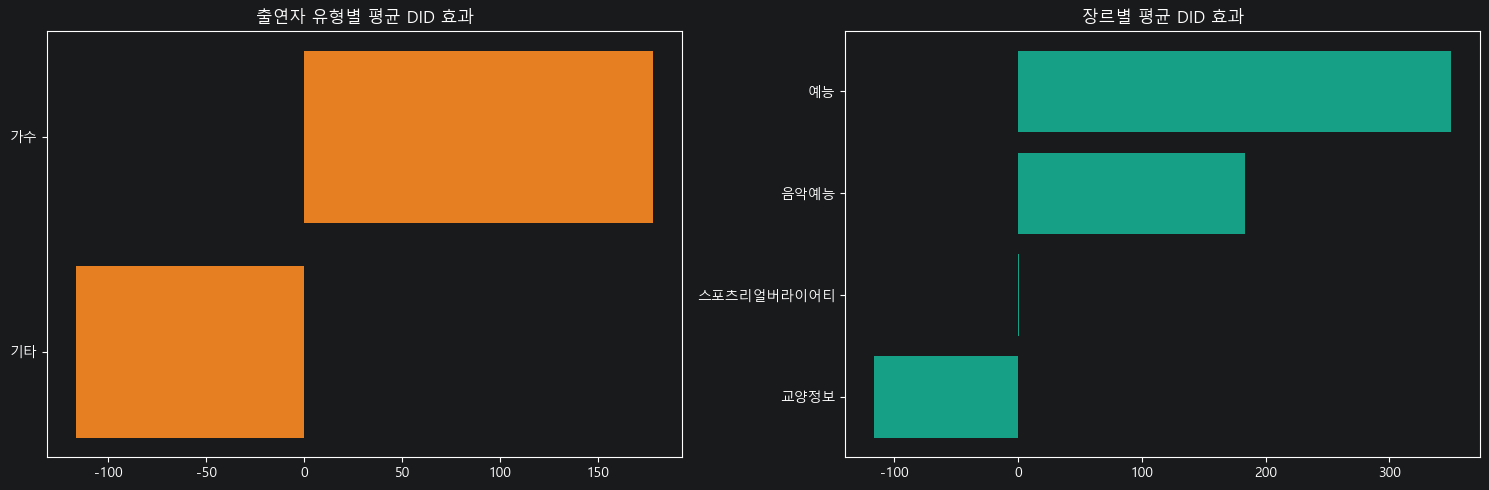

In [113]:
# 효과 + 특성 결합 (T맵 DID효과를 종속변수로)
meta = bdf[['name','genre','rating','budget_1000won']].rename(columns={'name':'프로그램명'})
meta = meta.merge(tmap_did[['프로그램명','DID_효과','DID_p']], on='프로그램명', how='left')
if len(cast_agg):
    meta = meta.merge(cast_agg, on='프로그램명', how='left')
print("=== 효과 × 특성 ===")
display(meta)

fig, axes = plt.subplots(1, 2, figsize=(15,5))
if '대표유형' in meta.columns and meta['대표유형'].notna().any():
    g = meta.dropna(subset=['DID_효과']).groupby('대표유형')['DID_효과'].mean().sort_values()
    axes[0].barh(g.index, g.values, color='#e67e22'); axes[0].set_title('출연자 유형별 평균 DID 효과')
gg = meta.dropna(subset=['DID_효과']).groupby('genre')['DID_효과'].mean().sort_values()
axes[1].barh(gg.index, gg.values, color='#16a085'); axes[1].set_title('장르별 평균 DID 효과')
plt.tight_layout(); plt.show()

In [ ]:
# 메타 해석 (N=6, 회귀 부적절 → 기술통계 + 방향성만 보고)
reg = meta.dropna(subset=['DID_효과']).copy()
reg['rating'] = pd.to_numeric(reg['rating'], errors='coerce')
print(f"표본: {len(reg)}건 → OLS 메타회귀 부적절 (자유도 부족). 기술통계로 해석.")

print("\n--- 장르별 평균 DID 효과 ---")
print(reg.groupby('genre')['DID_효과'].agg(['mean','count']).sort_values('mean', ascending=False))

if '대표유형' in reg.columns and reg['대표유형'].notna().any():
    print("\n--- 출연자 유형별 평균 DID 효과 ---")
    print(reg.groupby('대표유형')['DID_효과'].agg(['mean','count']).sort_values('mean', ascending=False))

print("\n--- 시청률 vs DID 효과 (상관) ---")
r_corr = reg[['rating','DID_효과']].dropna()
if len(r_corr) >= 3:
    corr = r_corr['rating'].corr(r_corr['DID_효과'])
    print(f"  Pearson r = {corr:.2f} (방향성 참고, 표본 {len(r_corr)}건으로 유의성 판단 불가)")
else:
    print("  상관 계산 불가 (결측 제외 표본 부족)")

print("\n※ 표본 규모상 인과적 해석 불가. 후속 연구에서 사례 축적 필요.")

## Part 6 — 공간 분석 (공간을 라벨이 아닌 분석 대상으로)

좌표가 위경도(WGS84), 거리·출발지·다음목적지·500m격자 모두 확보됨. 5개 모듈:
1. **유입 OD / 거리감쇠** — 방송 후 '더 먼 곳'에서 오는가?
2. **핫스팟 / KDE** — 방문 밀도가 어디로 이동했나?
3. **Spillover: Moran's I** — 인접 동 파급 (순열 검정 p-value 포함)
4. **동선 / 연계 네트워크** — 촬영지→다음 목적지 흐름
5. **500m 격자 정밀** — 격자 단위 매출 변화 히트맵

In [115]:
# ===== 7-1. 유입 OD / 거리감쇠 =====
def od_distance_shift(b, pre_days=28, post_days=28):
    air = b['air_date']; pois = broadcast_pois(b)
    if not pois or pd.isna(air): return None
    s = tmap[tmap['poi'].isin(pois)].copy()
    pre = s[(s['date']>=air-pd.Timedelta(days=pre_days)) & (s['date']<air)]
    post= s[(s['date']>=air) & (s['date']<air+pd.Timedelta(days=post_days))]
    if len(pre)==0 or len(post)==0: return None
    def wmean(d): return np.average(d['avg_drv_dstc'], weights=d['vst_cnt']) if d['vst_cnt'].sum() else np.nan
    def far(d):
        tot=d['vst_cnt'].sum()
        f=d[d['frst_dptre_ctpv_nm']!='충청남도']['vst_cnt'].sum()
        return f/tot*100 if tot else np.nan
    return {'프로그램명':b['name'],'평균거리_전':wmean(pre),'평균거리_후':wmean(post),
            '거리변화%':(wmean(post)-wmean(pre))/wmean(pre)*100 if wmean(pre) else np.nan,
            '원거리비율_전':far(pre),'원거리비율_후':far(post)}
od_df = pd.DataFrame([r for r in (od_distance_shift(b) for _,b in bdf[bdf['measurable']].iterrows()) if r])
print("=== 방송 전후 유입거리 변화 (도달범위 확장 여부) ===")
display(od_df)
print("※ 거리변화%>0 또는 원거리비율 상승 → 방송이 '더 먼 곳'에서 유입을 끌어냄")

=== 방송 전후 유입거리 변화 (도달범위 확장 여부) ===


,프로그램명,평균거리_전,평균거리_후,거리변화%,원거리비율_전,원거리비율_후
0,전국노래자랑 아산시편,11.67,10.81,-7.37,8.71,7.17
1,굿모닝 대한민국,18.87,18.94,0.36,33.20,34.09
2,박원숙의 같이삽시다 시즌3,15.15,14.72,-2.85,19.74,14.65
3,뛰어야산다2,10.28,9.76,-5.09,4.19,2.02


※ 거리변화%>0 또는 원거리비율 상승 → 방송이 '더 먼 곳'에서 유입을 끌어냄


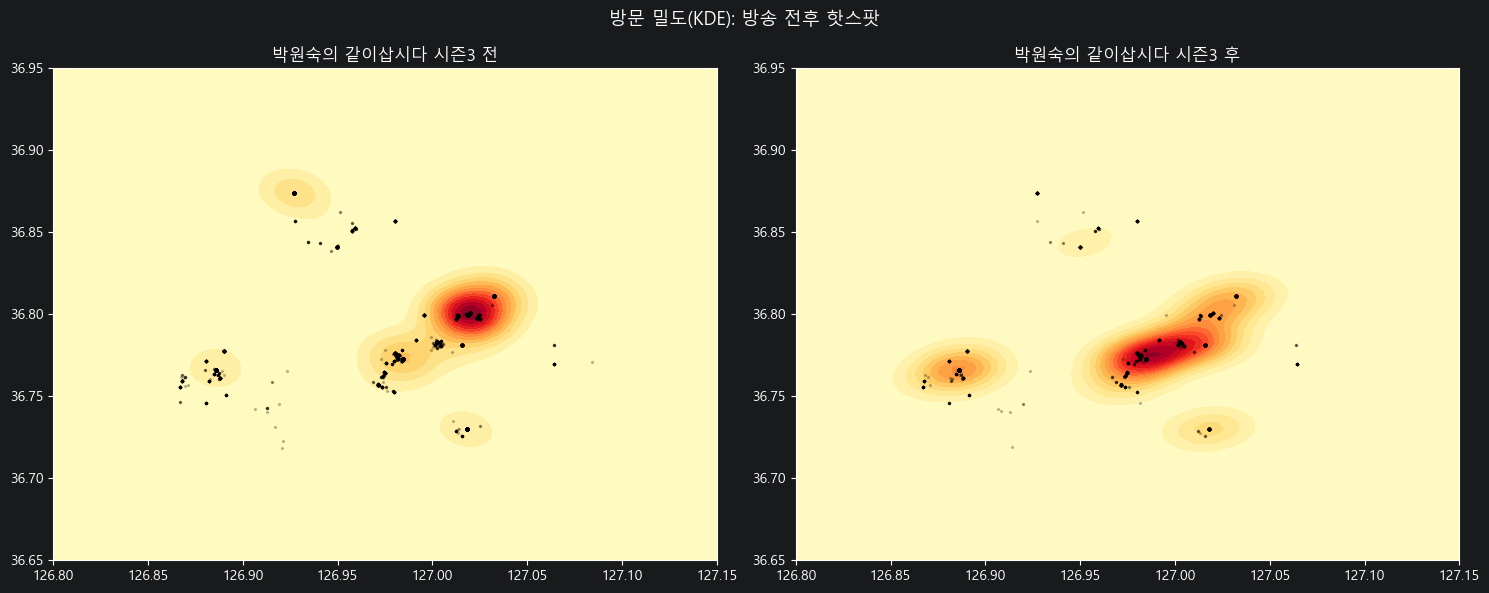

※ 대상: 박원숙의 같이삽시다 시즌3 (DID 효과 최대 방송)


In [116]:
# ===== 7-2. 핫스팟 / 커널밀도(KDE) =====
from scipy.stats import gaussian_kde
def kde_grid(df, gridn=80):
    d = df[['dstn_coord_x','dstn_coord_y','vst_cnt']].dropna()
    d = d[d['vst_cnt']>0]
    if len(d)<10: return None
    xy=np.vstack([d['dstn_coord_x'],d['dstn_coord_y']])
    try: k=gaussian_kde(xy, weights=d['vst_cnt'])
    except Exception: k=gaussian_kde(xy)
    xx,yy=np.mgrid[126.8:127.15:gridn*1j, 36.65:36.95:gridn*1j]
    zz=k(np.vstack([xx.ravel(),yy.ravel()])).reshape(xx.shape)
    return xx,yy,zz
best = od_df.merge(tmap_did[['프로그램명','DID_효과']], on='프로그램명', how='left').sort_values('DID_효과', ascending=False)
target = best.iloc[0]['프로그램명'] if len(best) else bdf.iloc[0]['name']
b = bdf[bdf['name']==target].iloc[0]; air=b['air_date']
s=tmap[tmap['poi'].notna()]
pre=s[(s['date']>=air-pd.Timedelta(days=28))&(s['date']<air)]
post=s[(s['date']>=air)&(s['date']<air+pd.Timedelta(days=28))]
fig,axes=plt.subplots(1,2,figsize=(15,6))
for ax,d,ttl in [(axes[0],pre,f'{target} 전'),(axes[1],post,f'{target} 후')]:
    g=kde_grid(d)
    if g:
        xx,yy,zz=g; ax.contourf(xx,yy,zz,levels=15,cmap='YlOrRd')
        ax.scatter(d['dstn_coord_x'],d['dstn_coord_y'],s=2,c='black',alpha=0.2)
    ax.set_title(ttl)
plt.suptitle('방문 밀도(KDE): 방송 전후 핫스팟', fontsize=13); plt.tight_layout(); plt.show()
print(f"※ 대상: {target} (DID 효과 최대 방송)")

In [ ]:
# ===== 6-3. Spillover: Moran's I (순열 검정 p-value 포함) =====
dong_xy = (tmap.dropna(subset=['dstn_dong_nm'])
           .groupby('dstn_dong_nm')[['dstn_coord_x','dstn_coord_y']].mean())

# 가장 넓은 노출 범위의 방송 선택 (하드코딩 제거)
target_b = bdf[bdf['measurable']].sort_values('air_date').iloc[
    bdf[bdf['measurable']]['dong_names'].apply(len).argmax()]
print(f"Spillover 대상: {target_b['name']} (노출 동 {len(target_b['dong_names'])}개)")

air = target_b['air_date']
ct = card_tour.copy()
pre = ct[(ct['week_start']>=air-pd.Timedelta(weeks=8))&(ct['week_start']<air)].groupby(dong_col)[amt_col].mean()
post = ct[(ct['week_start']>=air)&(ct['week_start']<air+pd.Timedelta(weeks=8))].groupby(dong_col)[amt_col].mean()
chg = ((post-pre)/pre*100).rename('change').to_frame().join(dong_xy, how='inner').dropna()

def morans_i(v, c):
    n = len(v); z = v - v.mean(); W = np.zeros((n,n))
    for i in range(n):
        for j in range(n):
            if i != j:
                d = np.hypot(c[i,0]-c[j,0], c[i,1]-c[j,1])
                W[i,j] = 1/d if d > 0 else 0
    rs = W.sum(axis=1)
    rs[rs==0] = 1
    W = W / rs[:, None]  # row-standardize
    num = sum(W[i,j]*z[i]*z[j] for i in range(n) for j in range(n))
    den = (z**2).sum() / n
    return num / den if den else np.nan

def morans_i_pvalue(v, c, n_perms=999):
    """순열 검정으로 Moran's I의 p-value 산출"""
    observed = morans_i(v, c)
    count = 0
    for _ in range(n_perms):
        perm = np.random.permutation(v)
        if abs(morans_i(perm, c)) >= abs(observed):
            count += 1
    return observed, (count + 1) / (n_perms + 1)

if len(chg) >= 5:
    I, p_val = morans_i_pvalue(chg['change'].values,
                                chg[['dstn_coord_x','dstn_coord_y']].values)
    print(f"\n=== Spillover ({target_b['name']} 방송 후 읍면동 소비변화) ===")
    print(f"Moran's I = {I:.3f}, p-value = {p_val:.3f} (순열 검정 999회)")
    print("  I>0 & p<0.05: 유의한 공간 군집(spillover)")
    print("  I≈0 또는 p>0.05: 파급 근거 부족")
    display(chg.sort_values('change', ascending=False)[['change']])
else:
    print("표본 부족 (읍면동 5개 미만)")

In [ ]:
# ===== 7-4. 동선 / 연계 네트워크 (next_dstn) =====
bx = target_b; air = bx['air_date']  # Part 6-3에서 선택한 방송
pois = broadcast_pois(bx)
s=tmap[(tmap['poi'].isin(pois))&(tmap['date']>=air)&(tmap['date']<air+pd.Timedelta(days=28))]
flows=[]
for _,r in s.iterrows():
    for col,cnt in [('frst_next_dstn_nm','frst_next_dstn_cnt'),
                    ('scnd_next_dstn_nm','scnd_next_dstn_cnt'),
                    ('thrd_next_dstn_nm','thrd_next_dstn_cnt')]:
        if pd.notna(r.get(col)):
            flows.append({'from':r['poi'],'to':r[col],'cnt':r.get(cnt,1) or 1})
fdf=pd.DataFrame(flows)
if len(fdf):
    top=fdf.groupby(['from','to'])['cnt'].sum().reset_index().sort_values('cnt',ascending=False).head(20)
    print(f"=== {bx['name']} 촬영지 → 다음 목적지 Top 20 ===")
    display(top)
    print("※ 연계 동선 = 방송효과가 흘러가는 상권. 정책: 경로 연계 마케팅.")
else:
    print("next_dstn 데이터 부족")

In [ ]:
# ===== 7-5. 500m 격자 정밀 분석 =====
gf = sorted(str(p) for p in BASE.glob('**/*WEEK_LC*500*SZ*.csv'))
print(f"격자 파일 {len(gf)}개")
gdfs=[]
for f in gf:
    try: gdfs.append(read_csv_auto(f))
    except Exception as e: print(f"  [!] {f}: {e}")
if gdfs:
    grid=pd.concat(gdfs, ignore_index=True)
    ymc = grid['CRTR_YM'] if 'CRTR_YM' in grid.columns else pd.Series([np.nan]*len(grid))
    grid['week_start']=[week_to_monday(w,y) for w,y in zip(grid['CRTR_WEEK'].astype('Int64'), ymc.astype('Int64'))]
    grid=grid[grid['week_start'].notna()]
    bx = target_b; air = bx['air_date']  # Part 6-3에서 선택한 방송
    pre=grid[(grid['week_start']>=air-pd.Timedelta(weeks=8))&(grid['week_start']<air)].groupby(['GRID_ID','COORD_X','COORD_Y'])['USE_AMT_SUM'].mean()
    post=grid[(grid['week_start']>=air)&(grid['week_start']<air+pd.Timedelta(weeks=8))].groupby(['GRID_ID','COORD_X','COORD_Y'])['USE_AMT_SUM'].mean()
    chg=((post-pre)/pre*100).rename('change').reset_index()
    chg=chg[np.isfinite(chg['change'])]
    fig,ax=plt.subplots(figsize=(10,9))
    sc=ax.scatter(chg['COORD_X'],chg['COORD_Y'],c=chg['change'].clip(-100,100),cmap='RdYlGn',s=40,vmin=-100,vmax=100)
    plt.colorbar(sc,label='매출 변화율 %')
    ax.set_title(f'{bx["name"]} 전후 500m 격자 매출변화'); plt.tight_layout(); plt.show()
    print(f"격자 {len(chg)}개. 초록=증가. 촬영지 좌표와 겹쳐 효과 집중도 확인.")
else:
    print("격자 파일 없음")

## Part 7 — 다중결과 교차검증 + 종합 리포트

In [ ]:
# ===== Part 6. 방송별 맞춤 측정 + 통합 매트릭스 =====
# 방송마다 노출형태가 달라 측정단위를 다르게 적용한다.
#   POI매칭 → 관광지 단위 DID/CI  |  전역노출 → 아산 전체(데이터랩+카드)  |  기간밖 → 측정불가

def card_total_change_rate(b, pre_w=8, post_w=4):
    """아산 전체 외지인 카드소비 방송 전후 변화율(%) — 전역노출 방송용."""
    air=b['air_date']
    t = card_tour.groupby('week_start')[amt_col].sum()
    pre = t[(t.index>=air-pd.Timedelta(weeks=pre_w))&(t.index<air)].mean()
    post= t[(t.index>=air)&(t.index<air+pd.Timedelta(weeks=post_w))].mean()
    if pd.isna(pre) or pd.isna(post) or pre==0: return np.nan
    return (post-pre)/pre*100

def measurement_level(b):
    if b['air_date'] > DATA_END: return '측정불가'
    return 'POI단위' if broadcast_pois(b) else '시전체'

rows=[]
for _, b in bdf.iterrows():
    lvl = measurement_level(b)
    row = {'프로그램명': b['name'], '측정수준': lvl}
    if lvl=='측정불가':
        row['효과지표']='-'; row['효과값']=np.nan; row['신뢰도']='데이터기간 밖(2026-05~)'
    elif lvl=='POI단위':
        dd = tmap_did[tmap_did['프로그램명']==b['name']]
        did = dd['DID_효과'].iloc[0] if len(dd) else np.nan
        pt  = dd['평행추세_p'].iloc[0] if len(dd) else np.nan
        row['효과지표']='T맵 DID(관광지)'; row['효과값']=did
        row['신뢰도']=('평행추세OK' if pt>0.05 else '평행추세위반') if pd.notna(pt) else '계산불가'
    else:  # 시전체
        # 데이터랩 소비 YoY 우선, 없으면 카드 전체 변화율
        yo = datalab_yoy[datalab_yoy['프로그램명']==b['name']]
        sval = yo['소비_전년대비%'].iloc[0] if (len(yo) and '소비_전년대비%' in yo.columns) else np.nan
        if pd.notna(sval):
            row['효과지표']='데이터랩 소비 YoY(시전체)'; row['효과값']=sval; row['신뢰도']='시 전체(방송외 요인 포함)'
        else:
            cv = card_total_change_rate(b)
            row['효과지표']='카드 외지인소비 변화율(시전체)'; row['효과값']=cv; row['신뢰도']='시 전체(방송외 요인 포함)'
    rows.append(row)

final = pd.DataFrame(rows)
print("="*78); print("  방송별 맞춤 측정 결과 (각 방송에 맞는 단위로)"); print("="*78)
import pandas as _pd
with _pd.option_context('display.max_colwidth', 30):
    display(final)

# 측정불가 외에 NaN이 남았는지 점검
remain = final[(final['측정수준']!='측정불가') & (final['효과값'].isna())]
if len(remain):
    print("\n[잔여 NaN — 추가 조치 필요]")
    display(remain[['프로그램명','측정수준','효과지표']])
else:
    print("\n✔ 측정가능 방송 전부 효과값 확보. (황제성만 기간밖으로 측정불가)")

final.to_csv(OUTPUT_DIR/'final_measurement_matrix.csv', index=False, encoding='utf-8-sig')
print("저장:", OUTPUT_DIR/'final_measurement_matrix.csv')